# Importing Relevant Libraries

In [ ]:
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from PIL import Image
import random
import pickle
import time
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import pickle


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set my file path
DATA_DIR = Path("/content/drive/MyDrive/gesture navigator project/gesture_dataset/raw")

In [ ]:
os.listdir(DATA_DIR)

['down', 'right', 'up', 'left', 'palm', 'peace']

In [ ]:
for folder in sorted(DATA_DIR.iterdir()):
    if folder.is_dir():
        print(
            f"{folder.name}: "
            f"{len(list(folder.glob('*')))} images")

down: 520 images
left: 700 images
palm: 999 images
peace: 867 images
right: 700 images
up: 973 images


In [ ]:
classes = []
counts = []

for folder in sorted(DATA_DIR.iterdir()):
    if folder.is_dir():
        classes.append(folder.name)
        counts.append(len(list(folder.glob('*'))))

df = pd.DataFrame({
    "Class": classes,
    "Count": counts
})

df

,Class,Count
0,down,520
1,left,700
2,palm,999
3,peace,867
4,right,700
5,up,973


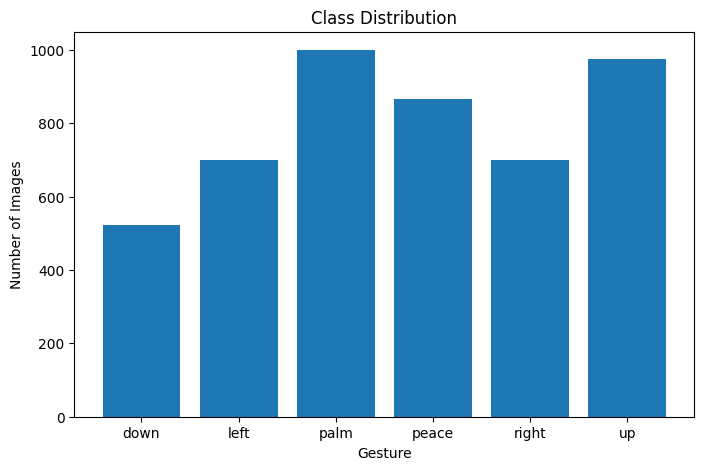

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df["Class"], df["Count"])
plt.xlabel("Gesture")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

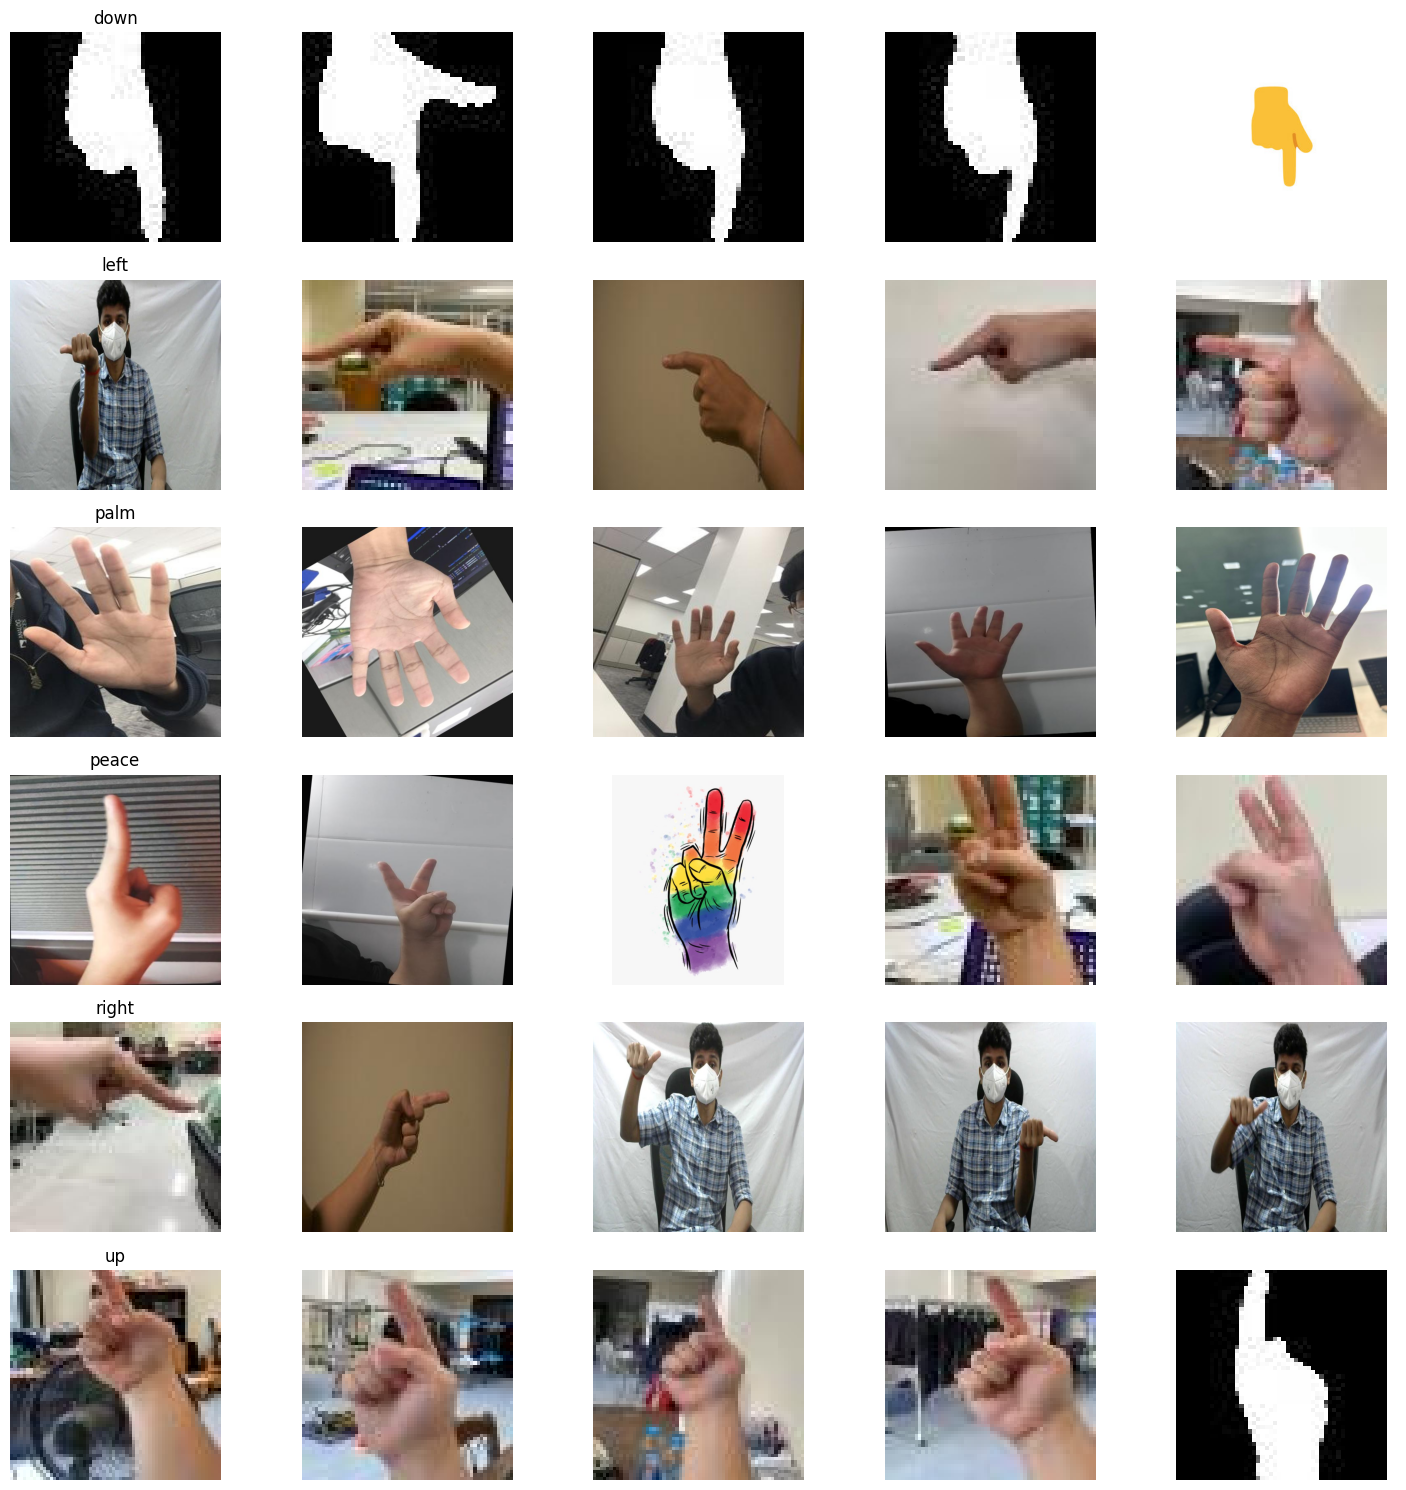

In [ ]:
fig, axes = plt.subplots(
    len(classes), 5,
    figsize=(15, 15))

for row, gesture in enumerate(classes):
    folder = DATA_DIR / gesture
    images = list(folder.glob('*'))

    samples = random.sample(
        images,
        min(5, len(images)))

    for col, img_path in enumerate(samples):
        img = Image.open(img_path)

        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        if col == 0:
            axes[row, col].set_title(gesture)

plt.tight_layout()
plt.show()

In [ ]:
sizes = []

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        for img_path in folder.glob('*'):

            try:
                img = Image.open(img_path)
                width, height = img.size
                sizes.append(
                    [folder.name, width, height])
            except:
                pass

size_df = pd.DataFrame(
    sizes,
    columns=[
        'class',
        'width',
        'height'])
size_df.head()

,class,width,height
0,down,416,416
1,down,260,280
2,down,600,900
3,down,600,900
4,down,840,481


In [ ]:
size_df.describe()

,width,height
count,4761.000000,4761.000000
mean,380.088217,376.693342
std,266.604164,277.799455
min,50.000000,50.000000
25%,64.000000,64.000000
50%,512.000000,512.000000
75%,640.000000,640.000000
max,2730.000000,3750.000000


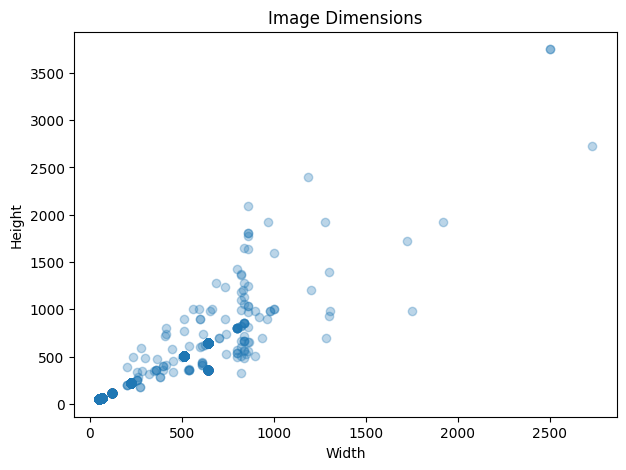

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    size_df['width'],
    size_df['height'],
    alpha=0.3)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Dimensions")
plt.show()

In [ ]:
bad_images = []

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        for img_path in folder.glob('*'):
            try:
                img = Image.open(img_path)
                img.verify()
            except:
                bad_images.append(img_path)
print(
    f"Corrupted images: {len(bad_images)}"
)

Corrupted images: 0


In [ ]:
size_df.groupby('class')[['width', 'height']].mean()

,width,height
class,,
down,242.074856,250.213052
left,317.880000,302.164286
palm,613.591592,607.705706
peace,412.349481,424.499423
right,343.981429,323.437143
up,256.356263,256.689938


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

splitfolders.ratio(
    input=DATA_DIR,
    output="/content/drive/MyDrive/gesture navigator project/gesture_dataset",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 4759 files [52:16,  1.52 files/s]


In [ ]:
BASE_DIR = Path(
    "/content/drive/MyDrive/gesture navigator project/gesture_dataset"
)

for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()}")

    split_path = BASE_DIR / split

    for cls in sorted(split_path.iterdir()):
        if cls.is_dir():
            print(
                f"{cls.name}: "
                f"{len(list(cls.glob('*')))}"
            )


TRAIN
down: 364
left: 489
palm: 699
peace: 606
right: 489
up: 681

VAL
down: 78
left: 105
palm: 149
peace: 130
right: 105
up: 145

TEST
down: 78
left: 106
palm: 151
peace: 131
right: 106
up: 147


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 3328 files belonging to 6 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 712 files belonging to 6 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 719 files belonging to 6 classes.


In [ ]:
class_names = train_ds.class_names

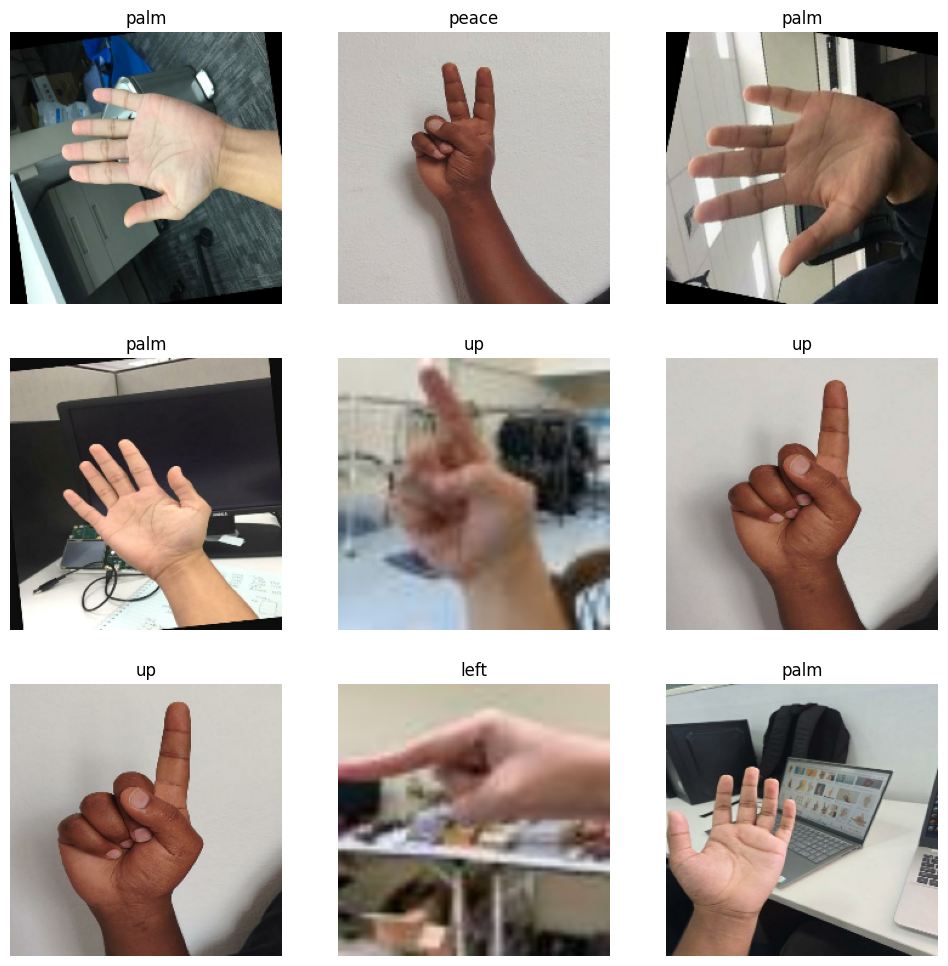

In [ ]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
print(tf.data.experimental.cardinality(train_ds))
print(tf.data.experimental.cardinality(val_ds))
print(tf.data.experimental.cardinality(test_ds))

tf.Tensor(104, shape=(), dtype=int64)
tf.Tensor(23, shape=(), dtype=int64)
tf.Tensor(23, shape=(), dtype=int64)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05)
])

In [ ]:
from PIL import Image
from pathlib import Path

bad_channels = []

for folder in DATA_DIR.iterdir():
    if folder.is_dir():

        for img_path in folder.glob("*"):

            try:
                img = Image.open(img_path)

                if img.mode != "RGB":
                    bad_channels.append(
                        (str(img_path), img.mode)
                    )

            except Exception as e:
                bad_channels.append(
                    (str(img_path), str(e))
                )

print(f"Found {len(bad_channels)} problematic images.")

Found 0 problematic images.


In [ ]:
for image_batch, labels_batch in train_ds.take(1):
    first_image = image_batch[0]

print(np.min(first_image), np.max(first_image))

4.1481705 255.0


# Baseline CNN Model

In [ ]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(224,224,3)
    ),

    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation='softmax')])

In [ ]:
baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'baseline_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 400s 4s/step - accuracy: 0.2894 - loss: 1.6654 - val_accuracy: 0.3848 - val_loss: 1.5388
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 457s 4s/step - accuracy: 0.4642 - loss: 1.3834 - val_accuracy: 0.4972 - val_loss: 1.3337
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 409s 4s/step - accuracy: 0.5159 - loss: 1.2420 - val_accuracy: 0.5169 - val_loss: 1.2088
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 377s 4s/step - accuracy: 0.5267 - loss: 1.1982 - val_accuracy: 0.5379 - val_loss: 1.1686
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 378s 4s/step - accuracy: 0.5442 - loss: 1.1495 - val_accuracy: 0.5843 - val_loss: 1.1731
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 393s 4s/step - accuracy: 0.5544 - loss: 1.0984 - val_accuracy: 0.5716 - val_loss: 1.0725
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 461s 4s/step - accuracy: 0.5718 - loss: 1.0443 - val_accuracy: 0.5548 - val_loss: 1.0679
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 454s 4s/step - accuracy: 0.5682 - loss: 1.0209 - val_accu

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6815 - loss: 0.7630
Test Accuracy: 0.6815


In [ ]:
y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

y_pred = np.argmax(
    baseline_model.predict(test_ds),
    axis=1
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 854ms/step


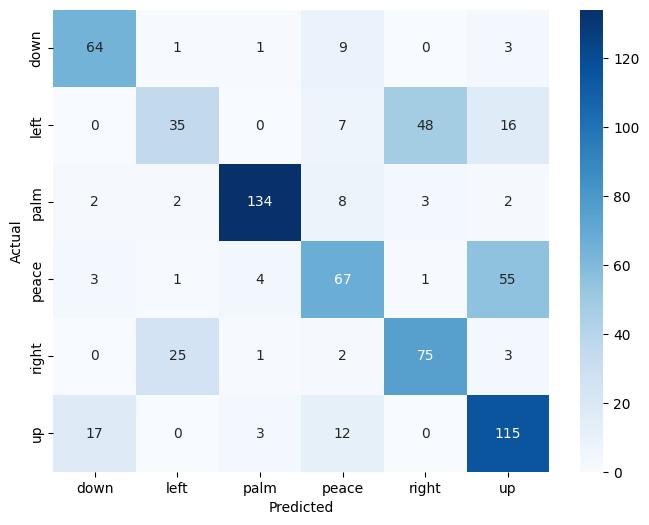

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        down       0.74      0.82      0.78        78
        left       0.55      0.33      0.41       106
        palm       0.94      0.89      0.91       151
       peace       0.64      0.51      0.57       131
       right       0.59      0.71      0.64       106
          up       0.59      0.78      0.67       147

    accuracy                           0.68       719
   macro avg       0.67      0.67      0.66       719
weighted avg       0.68      0.68      0.67       719



In [ ]:
"""baseline_model.save(
    "/content/drive/MyDrive/gesture navigator project/models/baseline_model.keras"
)"""

In [ ]:
results = pd.DataFrame({
    "Model":["Baseline CNN"],
    "Accuracy":[test_acc]
})

results

,Model,Accuracy
0,Baseline CNN,0.681502


In [ ]:

os.makedirs(
    "/content/drive/MyDrive/gesture navigator project/models",
    exist_ok=True
)

In [ ]:
loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/gesture navigator project/models/baseline_model.keras"
)

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Sun Jul  5 12:34:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.gpu_device_name())

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
/device:GPU:0


In [ ]:
tf.config.experimental.set_memory_growth(
    tf.config.list_physical_devices('GPU')[0],
    True
)

In [ ]:
with tf.device('/GPU:0'):
    a = tf.random.normal([10000,10000])
    b = tf.random.normal([10000,10000])
    c = tf.matmul(a,b)

In [ ]:
!nvidia-smi

Sun Jul  5 12:38:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             26W /   70W |    2167MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!cp -r "/content/drive/MyDrive/gesture navigator project/gesture_dataset" /content/

In [ ]:
BASE_DIR = Path("/content/gesture_dataset")
DATA_DIR = BASE_DIR / "raw"

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "train",
    image_size=(224,224),
    batch_size=32,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "val",
    image_size=(224,224),
    batch_size=32,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "test",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 3328 files belonging to 6 classes.
Found 712 files belonging to 6 classes.
Found 719 files belonging to 6 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (train_ds.cache().shuffle(1000).prefetch(AUTOTUNE))
val_ds = (val_ds.cache().prefetch(AUTOTUNE))
test_ds = (test_ds.cache().prefetch(AUTOTUNE))

In [ ]:
start = time.time()

for images, labels in train_ds.take(10):
    pass

print(time.time() - start)

7.183020114898682


## Baseline CNN (40 epochs, GPU resumed)

The baseline CNN was initially trained for 20 epochs in a standard runtime environment. To reduce training time, the model was saved, reloaded in a GPU-enabled runtime, and training was resumed for an additional 20 epochs, resulting in a total of 40 epochs.

In [ ]:
baseline_model = loaded_model

In [ ]:
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1
)

104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.6752 - loss: 0.7514 - val_accuracy: 0.6390 - val_loss: 0.7921


In [ ]:
!nvidia-smi

Sun Jul  5 13:53:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             31W /   70W |    4229MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.6977 - loss: 0.7185 - val_accuracy: 0.6882 - val_loss: 0.8373
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7055 - loss: 0.7141 - val_accuracy: 0.7317 - val_loss: 0.7376
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.7145 - loss: 0.6950 - val_accuracy: 0.7331 - val_loss: 0.8181
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7326 - loss: 0.6665 - val_accuracy: 0.7191 - val_loss: 0.7658
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7374 - loss: 0.6381 - val_accuracy: 0.7612 - val_loss: 0.6727
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7488 - loss: 0.6209 - val_accuracy: 0.7065 - val_loss: 0.7673
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.7722 - loss: 0.6039 - val_accuracy: 0.7430 - val_loss: 0.7552
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.7653 - loss: 0.5898 - val_acc

In [ ]:
!nvidia-smi

Sun Jul  5 13:58:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             30W /   70W |    4229MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
baseline_model.evaluate(test_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8526 - loss: 0.4882


[0.48819759488105774, 0.852573037147522]

In [ ]:
y_true = np.concatenate(
    [y.numpy() for x, y in test_ds],
    axis=0
)

y_pred = np.argmax(
    baseline_model.predict(test_ds),
    axis=1
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "train",
    image_size=(224,224),
    batch_size=32,
    seed=42
)

class_names = train_ds.class_names

Found 3328 files belonging to 6 classes.


In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        down       0.73      0.88      0.80        78
        left       0.90      0.95      0.93       106
        palm       0.95      0.89      0.92       151
       peace       0.83      0.69      0.75       131
       right       0.93      0.90      0.91       106
          up       0.76      0.84      0.80       147

    accuracy                           0.85       719
   macro avg       0.85      0.86      0.85       719
weighted avg       0.86      0.85      0.85       719



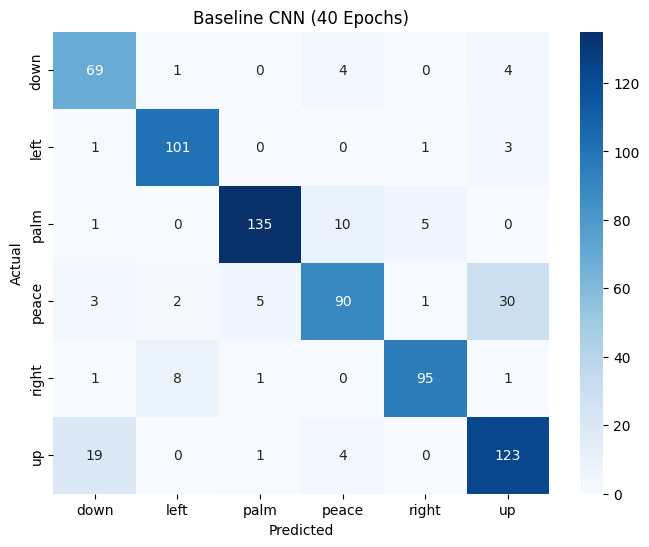

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline CNN (40 Epochs)")
plt.show()

In [ ]:
baseline_model.save(
    "/content/drive/MyDrive/gesture navigator project/models/baseline_cnn_40epochs.keras"
)

# Improved CNN

In [ ]:
improved_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same' ),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same' ),
    tf.keras.layers.Conv2D(64, (3,3),activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.Conv2D(128,(3,3), activation='relu', padding='same' ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [ ]:
improved_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,294 (1.16 MB)

 Trainable params: 304,294 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/gesture navigator project/models/improved_cnn.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
history_improved = improved_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 31s 135ms/step - accuracy: 0.2539 - loss: 1.6736 - val_accuracy: 0.3020 - val_loss: 1.6207
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.3359 - loss: 1.5847 - val_accuracy: 0.3525 - val_loss: 1.5966
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 0.3738 - loss: 1.5095 - val_accuracy: 0.3792 - val_loss: 1.4999
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.3945 - loss: 1.4617 - val_accuracy: 0.4382 - val_loss: 1.4156
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 0.4669 - loss: 1.2828 - val_accuracy: 0.5112 - val_loss: 1.1882
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - accuracy: 0.5249 - loss: 1.1268 - val_accuracy: 0.5211 - val_loss: 1.1133
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step - accuracy: 0.5523 - loss: 1.0599 - val_accuracy: 0.5309 - val_loss: 1.0794
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.5730 - loss: 1

In [ ]:
improved_cnn.evaluate(test_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8776 - loss: 0.3269


[0.32694196701049805, 0.8776077628135681]

In [ ]:
y_true_2 = np.concatenate(
    [y.numpy() for x, y in test_ds],
    axis=0
)

y_pred_2 = np.argmax(
    improved_cnn.predict(test_ds),
    axis=1
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [ ]:
print(
    classification_report(
        y_true_2,
        y_pred_2,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        down       0.94      0.86      0.90        78
        left       0.95      0.95      0.95       106
        palm       0.96      0.91      0.94       151
       peace       0.77      0.63      0.69       131
       right       0.96      0.95      0.96       106
          up       0.76      0.96      0.85       147

    accuracy                           0.88       719
   macro avg       0.89      0.88      0.88       719
weighted avg       0.88      0.88      0.88       719



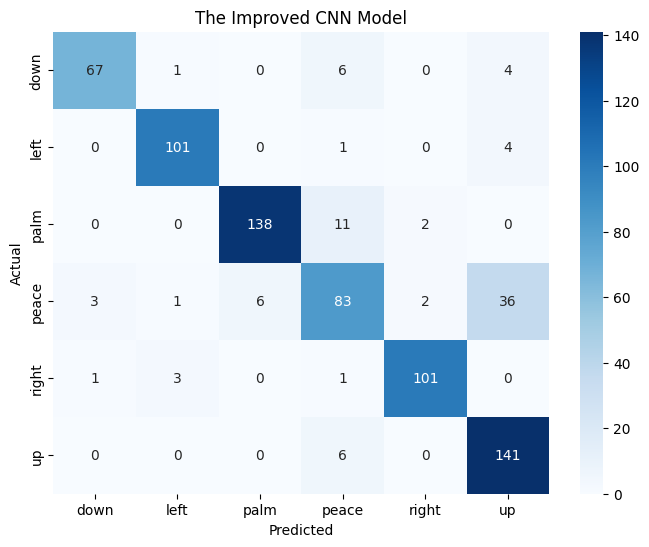

In [ ]:
cm = confusion_matrix(y_true_2, y_pred_2)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("The Improved CNN Model")
plt.show()

In [ ]:
improved_cnn.save(
    "/content/drive/MyDrive/gesture navigator project/models/improved_cnn.keras"
)

# EfficientNetB0 Model

In [ ]:
efficientnet_base = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

efficientnet_base.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
efficientnet_model = models.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    data_augmentation,

    #layers.Rescaling(1./255),

    efficientnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [ ]:
efficientnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop_eff = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_eff = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/gesture navigator project/models/efficientnet_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
history_eff = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stop_eff,
        checkpoint_eff
    ]
)

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 34s 153ms/step - accuracy: 0.4925 - loss: 1.3691 - val_accuracy: 0.7205 - val_loss: 0.9100
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.6992 - loss: 0.8674 - val_accuracy: 0.8287 - val_loss: 0.6396
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.7809 - loss: 0.6661 - val_accuracy: 0.8624 - val_loss: 0.5100
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.8185 - loss: 0.5509 - val_accuracy: 0.8848 - val_loss: 0.4300
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.8410 - loss: 0.4805 - val_accuracy: 0.8933 - val_loss: 0.3801
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.8564 - loss: 0.4266 - val_accuracy: 0.9017 - val_loss: 0.3420
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.8651 - loss: 0.3910 - val_accuracy: 0.9143 - val_loss: 0.3168
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.8828 - loss: 0

In [ ]:
test_loss_eff, test_acc_eff = efficientnet_model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc_eff:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9513 - loss: 0.1301
Test Accuracy: 0.9513


In [ ]:
y_true_eff = np.concatenate(
    [y.numpy() for x, y in test_ds],
    axis=0
)

y_pred_eff = np.argmax(
    efficientnet_model.predict(test_ds),
    axis=1
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step


In [ ]:
print(
    classification_report(
        y_true_eff,
        y_pred_eff,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

        down       0.97      1.00      0.99        78
        left       0.81      0.99      0.89       106
        palm       1.00      0.98      0.99       151
       peace       0.95      0.98      0.97       131
       right       1.00      0.76      0.87       106
          up       0.99      0.97      0.98       147

    accuracy                           0.95       719
   macro avg       0.95      0.95      0.95       719
weighted avg       0.96      0.95      0.95       719



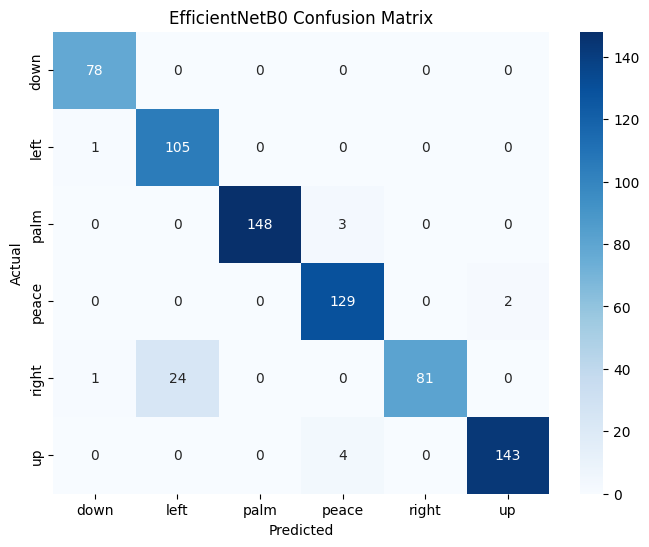

In [ ]:
cm = confusion_matrix(
    y_true_eff,
    y_pred_eff
)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

In [ ]:
efficientnet_model.save(
    "/content/drive/MyDrive/gesture navigator project/models/efficientnet_model.keras"
)

# Last

In [ ]:
with open(
    "/content/drive/MyDrive/gesture navigator project/models/efficientnet_history.pkl",
    "wb"
) as f:
    pickle.dump(history_eff.history, f)

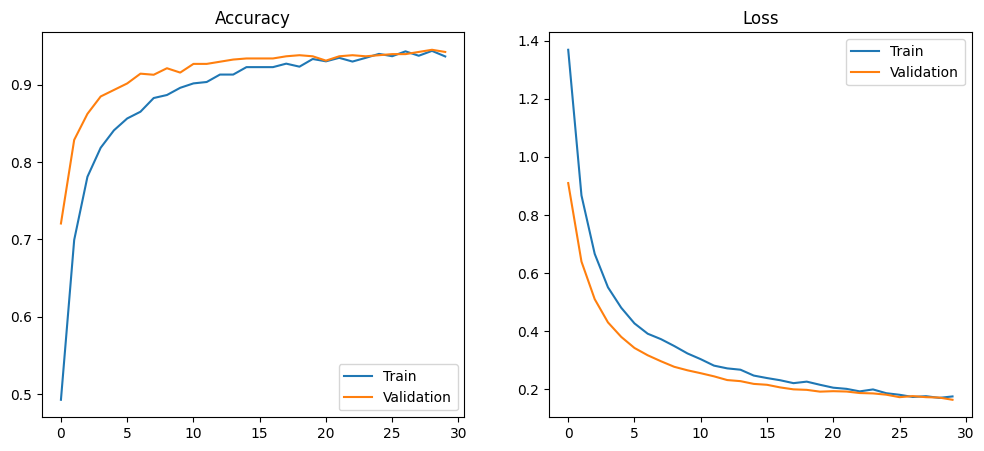

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_eff.history['accuracy'])
plt.plot(history_eff.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history_eff.history['loss'])
plt.plot(history_eff.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Baseline CNN",
        "Baseline CNN (40 Epochs)",
        "Improved CNN",
        "EfficientNetB0"
    ],
    "Accuracy":[
        0.6815,
        0.8526,
        0.8776,
        0.9513
    ]
})

results

,Model,Accuracy
0,Baseline CNN,0.6815
1,Baseline CNN (40 Epochs),0.8526
2,Improved CNN,0.8776
3,EfficientNetB0,0.9513
